In [3]:
import pandas as pd
url = 'https://opendata.cern.ch/record/700/files/MuRun2010B.csv'
data = pd.read_csv(url)
masses = data['M']  # invariant mass

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

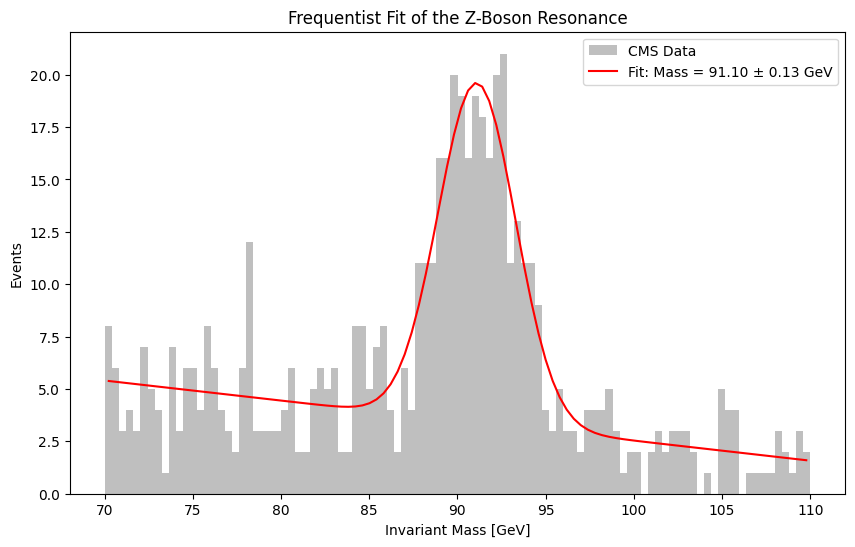

Measured Z-boson mass: 91.104 GeV
Statistical Uncertainty: 0.128 GeV


In [6]:
z_region = masses[(masses > 70) & (masses < 110)]

counts, bin_edges = np.histogram(z_region, bins=100)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Define our Model: Signal (Gaussian) + Background (Linear/Exponential)
# Based on the lecture, we assume Gaussian noise/scatter for the peak
def model(x, mass, sigma, amplitude, slope, intercept):
    # Gaussian signal
    signal = amplitude * np.exp(-(x - mass)**2 / (2 * sigma**2))
    # Linear background
    background = slope * x + intercept
    return signal + background

# Perform the Fit (Frequentist Chi-Squared Minimization)
# Initial guesses: mass ~ 91 GeV, sigma ~ 2 GeV
initial_guess = [91, 2, max(counts), -1, 100]
popt, pcov = curve_fit(model, bin_centers, counts, p0=initial_guess)

# Extract results and uncertainties (sqrt of diagonal of covariance matrix)
fit_mass, fit_sigma = popt[0], popt[1]
mass_error = np.sqrt(pcov[0,0])

# Visualize the results
plt.figure(figsize=(10, 6))
plt.hist(z_region, bins=100, alpha=0.5, label='CMS Data', color='gray')
plt.plot(bin_centers, model(bin_centers, *popt), 'r-', label=f'Fit: Mass = {fit_mass:.2f} ± {mass_error:.2f} GeV')
plt.xlabel('Invariant Mass [GeV]')
plt.ylabel('Events')
plt.title('Frequentist Fit of the Z-Boson Resonance')
plt.legend()
plt.show()

print(f"Measured Z-boson mass: {fit_mass:.3f} GeV")
print(f"Statistical Uncertainty: {mass_error:.3f} GeV")